In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}



!pip install git+https://github.com/lshofsl/EngramNCA
!git clone --depth 1 --filter=blob:none --sparse https://github.com/lshofsl/EngramNCA.git
!cd EngramNCA/ && git sparse-checkout set Images
!mkdir Images && mv EngramNCA/Images/* Images && rm -rf EngramNCA

  Cloning https://github.com/lshofsl/EngramNCA to /tmp/pip-req-build-jbl391hw
  Running command git clone --filter=blob:none --quiet https://github.com/lshofsl/EngramNCA /tmp/pip-req-build-jbl391hw
  Resolved https://github.com/lshofsl/EngramNCA to commit 47d86c2cdf0c6150ee1610fdbd832ab0edba7712
  Preparing metadata (setup.py) ... done
  Created wheel for GeneCA: filename=GeneCA-0.1-py3-none-any.whl size=6734 sha256=616311ffe98bff16ed8556cb292c984f592e8b664024828b6c996ad2df61dfde
  Stored in directory: /tmp/pip-ephem-wheel-cache-llk6iih8/wheels/05/3a/ae/9ba973a799c0f387052317339c512df60037043e2c52613071
Successfully built GeneCA
Cloning into 'EngramNCA'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), done.
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressi

In [2]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA.NCA import *
import NCA.utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [43]:
#@title Setup { vertical-output: true}
HEIGHT = 30 #@param {type:"integer"}
WIDTH = 30 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
GENE_COUNT = 3 #@param {type:"integer"} <-- Number of gene channels to use for "private" information
RECURRENT_CHANNELS = 3 #@param {type:"integer"} <-- Number of channels for RA computation, these channels are not updated by the NCA and are only used for recurrent processing
MODULATORY_OUTPUT = 3 #@param {type:"integer"} <-- Number of channels for modulatory output, these channels are not updated  and only show the output of the NCA
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size
PRIMITIVES_SHAPES = ["Images/square.png", "Images/circle.png", "Images/triangle.png"]
PRIMITIVES_BODY_PARTS = ["Images/Torso.png", "Images/Head.png", "Images/Tail.png", "Images/leg1.png", "Images/leg2.png", "Images/leg3.png", 'Images/leg4.png']
PRIMITIVES_LINES = ["Images/horizontal.png", "Images/Verical.png"]
style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [44]:
#@title Load Primitives { vertical-output: true}

paths = PRIMITIVES_SHAPES #@param {type:"string"}
images = []
images_to_display = []
for path in paths:
    image, image_to_display = utils.get_image(path, HEIGHT, WIDTH, padding=PADDING)
    images.append(image)
    images_to_display.append(image_to_display)

genes = [[0], [1], [2]] # <-- Gene one hot encoding, indicates which bits if the gene sequence for each encoded "image" should be 1, [0] = 001, [0,1] = 011, [2] = 100 etc. for 3 bits genes. One, one-hot encoding per image, this rule applies for any gene size

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING
assert len(paths) == len(genes), 'Genes and images should have the same length '

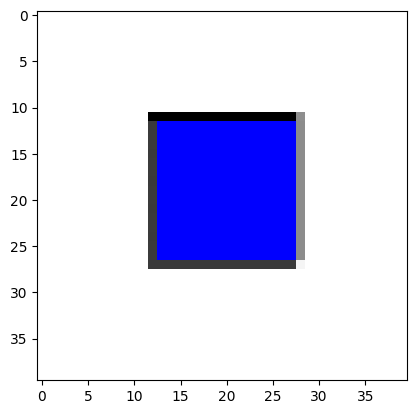

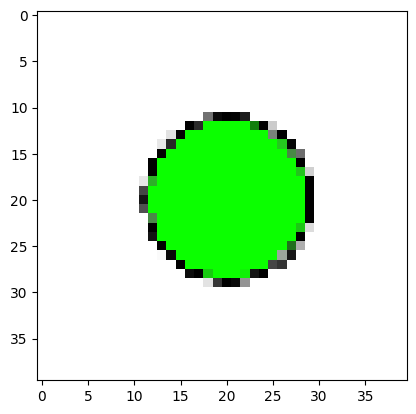

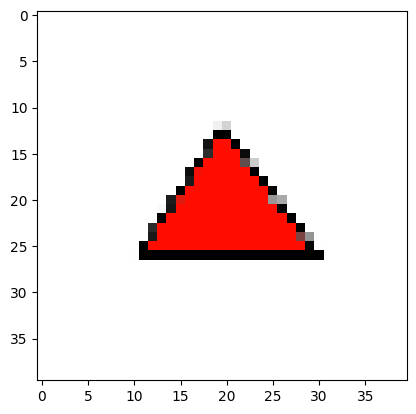

In [45]:
#@title Display Primitives { vertical-output: true}
for i,image in enumerate(images_to_display):
    plt.figure(3+i)
    plt.imshow(image)
pools = []
for gene in genes:
    pools.append(utils.make_gene_pool(gene, pool_size=POOL_SIZE,height=HEIGHT, width=WIDTH, channels=CHANNELS, gene_size=GENE_COUNT, device=DEVICE))
seeds = []
for pool in pools:
    seeds.append(pool[0].clone())

In [46]:
#@title Get Batch Image Partitions { vertical-output: true}
partitions = len(paths)
if partitions == 1:
    part = [BATCH_SIZE]
div = BATCH_SIZE//partitions
rem = BATCH_SIZE % partitions
part = [div + 1 if i < rem else div for i in range(partitions)]
print(f"Batch image paritions = {part}. Batch Size of {BATCH_SIZE}. Number of Partitions = {partitions}")

Batch image paritions = [4, 4, 4]. Batch Size of 12. Number of Partitions = 3


In [47]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [48]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene already exists, all OK!


In [49]:
#@title Initialise NCA { vertical-output: true}
bases = [images[i].tile(part[i],1,1,1) for i in range(len(part))]
base = torch.cat(bases, dim =0 ).to(DEVICE)
loss_log = []
nca = GeneCA(CHANNELS,HIDDEN_SIZE, gene_size=GENE_COUNT)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__ + "_gene_size_" +str(GENE_COUNT)

To integrate an energy-gradient foundation into our framework, we modify the forward pass of the NCA by incorporating a static Hopfield-style energy function:
$$E = \frac{1}{2}||s||^2$$
Where the energy gradient with respect s is
$$\Delta_s E = -s$$


By incorporating this into our cellular automaton update rule, we introduce a positive feedback mechanism. Active states with positive values are driven to become more positive, while negative states become more negative, forcefully pushing the cellular state away from zero and making the dynamics energy-driven.

During training, the loss function is extended with a scalar energy
regularization term. This ensures that the optimization accounts not
only for morphological reconstruction but also for the energy profile
of the generated state:

$$\mathcal{L} = \mathcal{L}_{\text{morphology}} + \alpha \cdot E(s_t)$$

where $s_t$ is the current cell state and $\alpha$ is a regularization
hyperparameter. The morphology loss is the pixelwise MSE over the
visible channels:

$$\mathcal{L}_{\text{morphology}} = \frac{1}{H \times W \times C}
\| s_t[0:4] - \hat{s}[0:4] \|^2$$

where $\hat{s}$ denotes the target image and the index $[0:4]$
selects the visible RGBA channels.

Batch


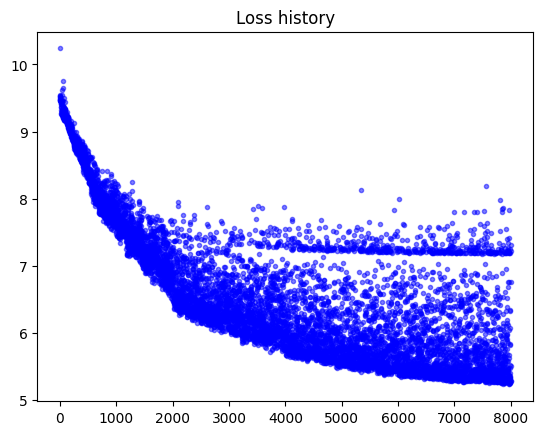

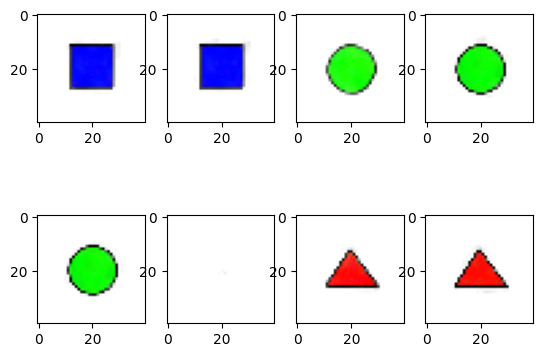

Trained_models/Gene/GeneCA_gene_size_3.pth


In [50]:
#@title Training { vertical-output: true}
energy = []

for i in range(TRAINING_ITERS + 1):
    loss = 0
    with torch.no_grad():
        idxs, x = utils.get_gene_pool(pools, part, seeds)

    for _ in range( random.randrange(32,92)):
        x = nca(x)

    loss_base = (base - x[:, :4, :, :]).pow(2).sum() + 0.1 *(perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters) ).pow(2).sum()
    ## We add an energy constrain on the loss
    energy_target = -0.5 * torch.sum(base.pow(2))  ##Energy of the target
    energy_nca_state = -0.5 * torch.sum(x[:, :4, :, :].pow(2))
    energy.append(energy_nca_state.item())
    ## Total loss of the energy targets
    loss_energy = (energy_target - energy_nca_state).pow(2)

    gamma = 0.01  ## Hyperparameter
    loss = loss_base + gamma * loss_energy


    with torch.no_grad():
        loss.backward()
        for p in nca.parameters():
            p.grad /= (p.grad.norm() + 1e-8)
        optim.step()

        x = x.detach()
        optim.zero_grad()

    loss_log.append(loss.log().item())
    with torch.no_grad():
        pools = utils.udate_gene_pool(pools, x.clone().detach(), idxs, part)
    scheduler.step()

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)
    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")



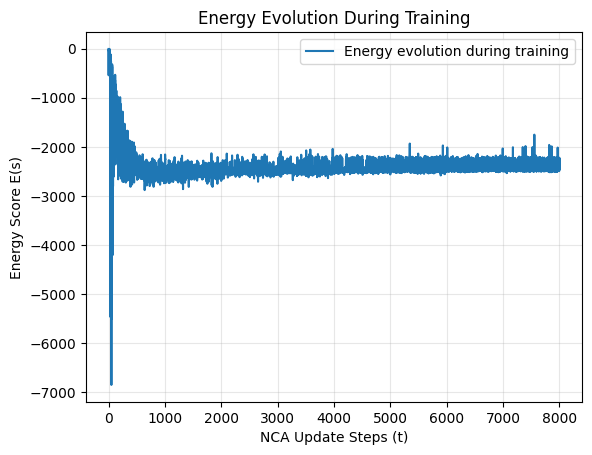

In [51]:
plt.plot(range(TRAINING_ITERS + 1), energy, label="Energy evolution during training")
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Energy Score E(s)")
plt.title("Energy Evolution During Training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [52]:
nca = GeneCA(CHANNELS,hidden_n=HIDDEN_SIZE, gene_size=GENE_COUNT)
nca.load_state_dict(torch.load("Trained_models/Gene/GeneCA_gene_size_3.pth"))
nca.to(DEVICE).eval()

GeneCA(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 7, kernel_size=(1, 1), stride=(1, 1), bias=False)
)

Now we can test the model, first we analyse how good is to grow a morphology and mantain the shape. Therefore we can analyse the energy function during the training and observed if it reach a minimun, as we are storing 3 shapes, we should observe 3 valleys

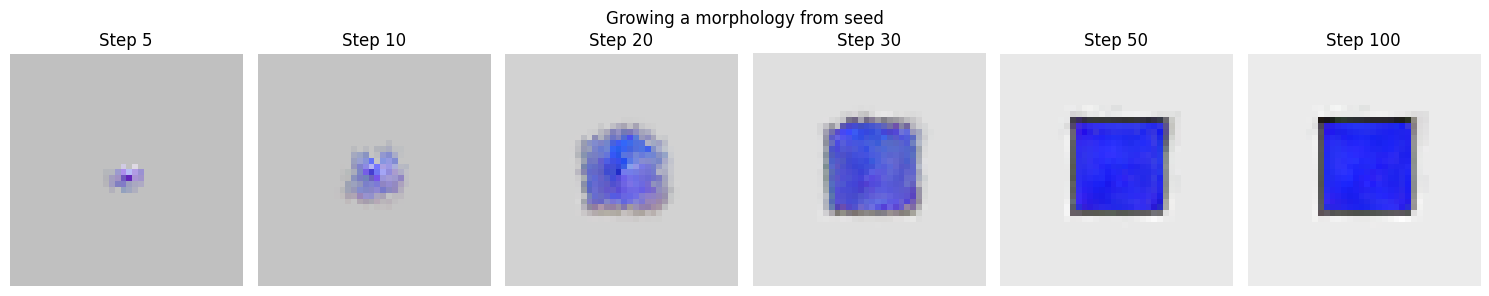

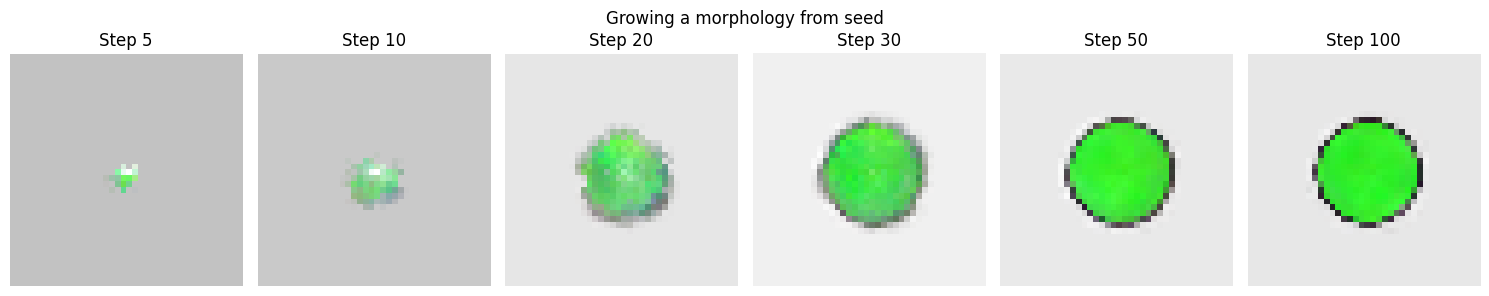

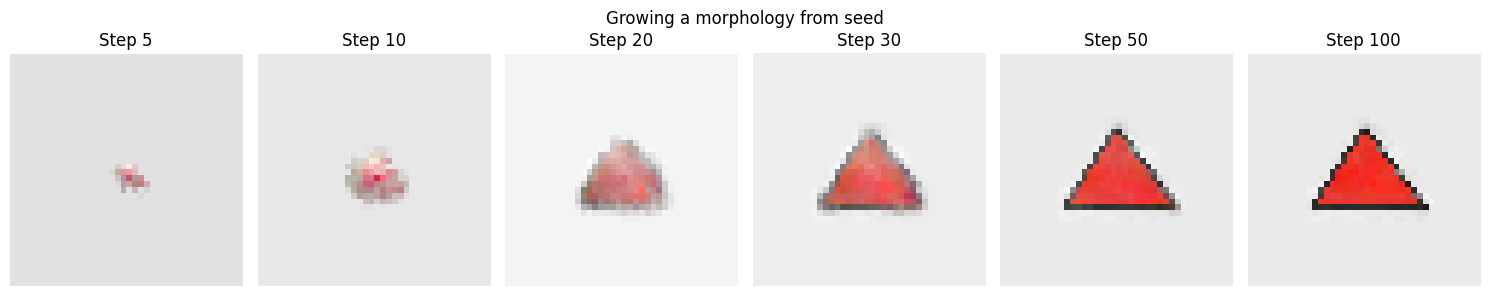

In [69]:

## Growing the morphology
def visualize_growth(nca, seed, steps_to_show=[5, 10, 20, 30, 50, 100]):
    x = seed.clone()
    fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
    fig.suptitle("Growing a morphology from seed")

    current_step = 0
    with torch.no_grad():
        for i, target_step in enumerate(steps_to_show):
            steps_needed = target_step - current_step
            for _ in range(steps_needed):
                x = nca(x)
            current_step = target_step

            # Show RGB channels
            img = x[0, :4].permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            axes[i].imshow(img)
            axes[i].set_title(f"Step {target_step}")
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Call it with a fresh seed
visualize_growth(nca, seeds[0].unsqueeze(0).to(x.device))
visualize_growth(nca, seeds[1].unsqueeze(0).to(x.device))
visualize_growth(nca, seeds[2].unsqueeze(0).to(x.device))


In [77]:
def visualize_energy_during_growth(nca, make_seed_fn, n_shapes=3,
                                    total_steps=100, channels=4, device=DEVICE):
    """
    Tracks energy E(s) = -0.5 * ||s||^2 as each morphology grows from a seed.
    make_seed_fn(shape_idx) should return a fresh seed tensor for that shape.
    """
    shape_names = {0: "Square", 1: "Circle", 2: "Triangle"}
    colors      = {0: "blue",   1: "limegreen", 2: "red"}

    energies_per_shape = {i: [] for i in range(n_shapes)}
    steps = np.arange(0, total_steps)

    with torch.no_grad():
        for shape_idx in range(n_shapes):
            # Fresh seed for each shape, weights on zero
            x = make_seed_fn(shape_idx).to(device)

            for t in steps:
                x = nca(x)
                e = -0.5 * torch.sum(x[:, :channels, ...].pow(2)).item()
                energies_per_shape[shape_idx].append(e)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Energy Evolution During Morphological Growth", fontsize=13)



    #  early steps only
    early = 30
    ax1 = axes[0]
    for i in range(n_shapes):
        ax1.plot(steps[:early], energies_per_shape[i][:early],
                 label=f"Valley {i+1}: {shape_names[i]}",
                 color=colors[i], linewidth=2)
        # Mark where energy stabilizes (first time derivative < threshold)
        diffs = np.abs(np.diff(energies_per_shape[i][:early]))
        stable_idx = next((j for j, d in enumerate(diffs) if d < 1.0), None)
        if stable_idx:
            ax1.axvline(x=stable_idx, color=colors[i],
                       linestyle='--', alpha=0.4)
    ax1.set_title("Early Steps (Growth Phase)")
    ax1.set_xlabel("NCA Update Steps (t)")
    ax1.set_ylabel("Energy Score E(s)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()


    #  full growth window
    ax2 = axes[1]
    for i in range(n_shapes):
        ax2.plot(steps, energies_per_shape[i],
                 label=f"Valley {i+1}: {shape_names[i]}",
                 color=colors[i], linewidth=2)
    ax2.set_title("Full Growth Window")
    ax2.set_xlabel("NCA Update Steps (t)")
    ax2.set_ylabel("Energy Score E(s)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return energies_per_shape

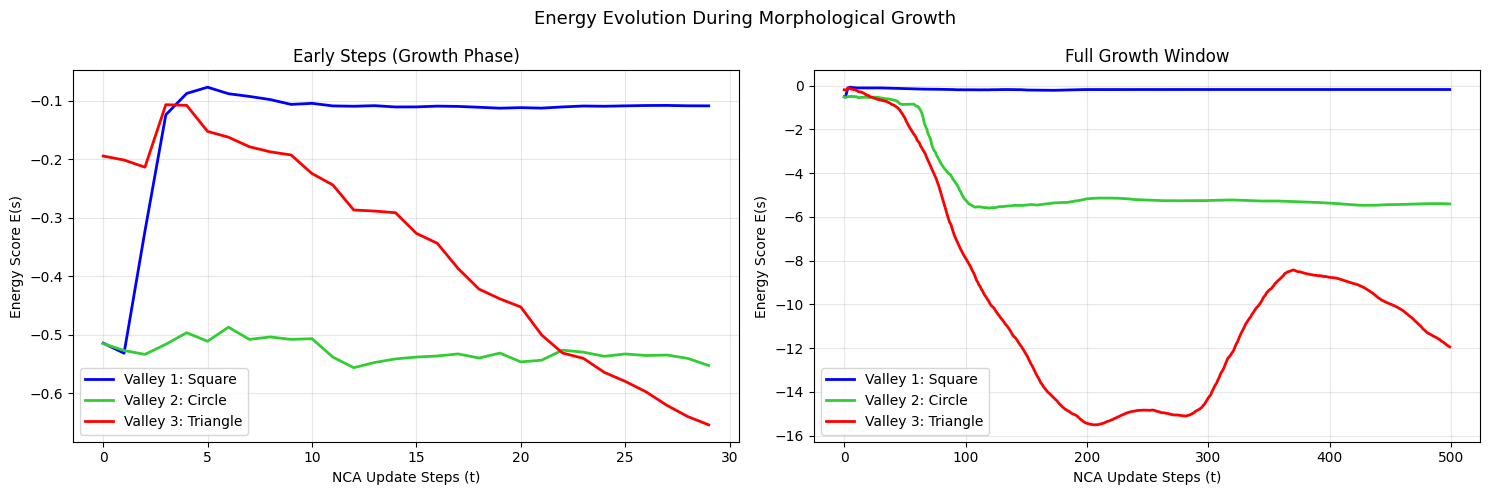

In [80]:
def make_fresh_seed(shape_idx):
    """
    Returns a fresh seed tensor with the gene encoding for shape_idx.
    Adjust to match how your seeds/pools are structured.
    """
    # Create an empty grid
    seed = torch.zeros(1, nca.chn, HEIGHT, WIDTH, device=DEVICE)

    # Place a single alive seed cell in the center
    seed[:, 3, HEIGHT//2, WIDTH//2] = 1.0  # alpha channel

    # Set the gene encoding for this shape (binary, as in EngramNCA)
    gene_start = nca.chn - nca.channels  # index where gene channels start
    gene_encoding = torch.zeros(nca.gene_size, device=DEVICE)
    gene_encoding[shape_idx] = 1.0       # one-hot encoding
    seed[:, gene_start:gene_start + nca.gene_size, HEIGHT//2, WIDTH//2] = gene_encoding

    return seed

# Run it
energies = visualize_energy_during_growth(
    nca=nca,
    make_seed_fn=make_fresh_seed,
    n_shapes=3,
    total_steps=500,
    channels=4,
    device=DEVICE
)

In [42]:
del nca
del optim
torch.cuda.empty_cache()